In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, distances
from MDAnalysis.analysis.dihedrals import Dihedral
import MDAnalysis.analysis.atomicdistances as ad
from MDAnalysis.analysis import helix_analysis as hel
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nglview as nv
import warnings
from tqdm import tqdm
from openmm import unit

from deeptime.decomposition import TICA
from deeptime.clustering import KMeans
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.markov import pcca
from deeptime.markov.tools.analysis import timescales_from_eigenvalues

warnings.filterwarnings('ignore')

In [2]:
states = ("holo", "cys-loaded")
ffs = ["ff19sb"]
water_models = ["opc"]
replicate_ids = (1, 2, 3)

prefixes = [
    f"{state}/{ff}/{water_model}"
    for state in states
    for ff in ffs
    for water_model in water_models
]

In [3]:
cv_data = {}
for prefix in prefixes:
    pp_vecs_list = []
    for replicate_id in replicate_ids:
        u = mda.Universe(f"../workspace/{prefix}/{replicate_id}/production_trimmed_static_vacuum.pdb", f"../workspace/{prefix}/{replicate_id}/production_trimmed_static_vacuum.dcd", in_memory=True)
        pp_vecs = np.array([
            u.select_atoms("resnum 38 and name CP8").atoms[0].position - u.select_atoms("resnum 38 and name PD").atoms[0].position
            for ts in tqdm(u.trajectory)
        ])
        pp_vecs_list.append(pp_vecs)

    pp_vecs = np.concatenate(pp_vecs_list, axis=0)

    rs = np.linalg.norm(pp_vecs, axis=1)
    thetas = np.arccos(pp_vecs[:, 2] / rs)
    phis = np.arctan2(pp_vecs[:, 1], pp_vecs[:, 0])

    theta_tiled = np.concatenate([thetas, thetas, thetas])
    phi_tiled = np.concatenate([phis - 2 * np.pi, phis, phis + 2 * np.pi])

    cv_data[prefix] = (theta_tiled, phi_tiled)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:08<00:00, 6216.19it/s]


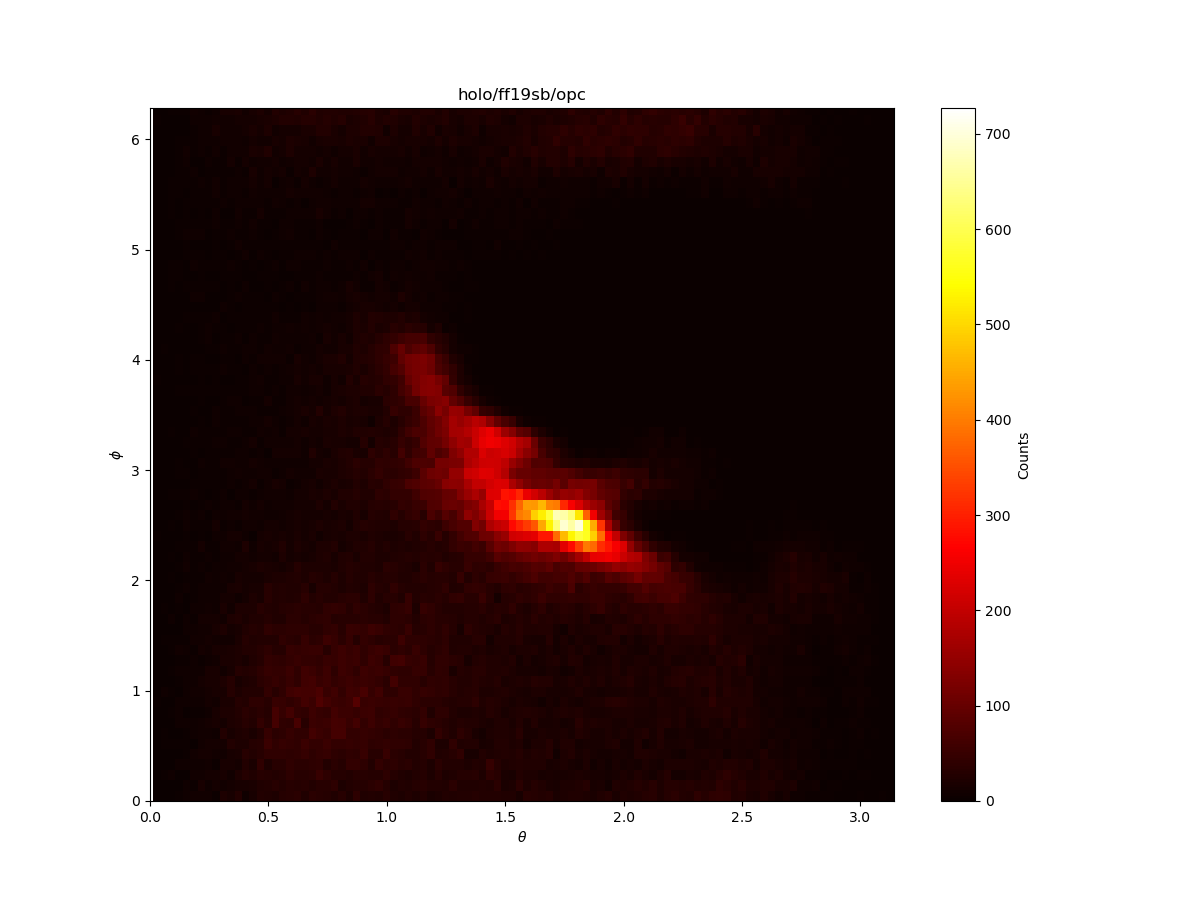

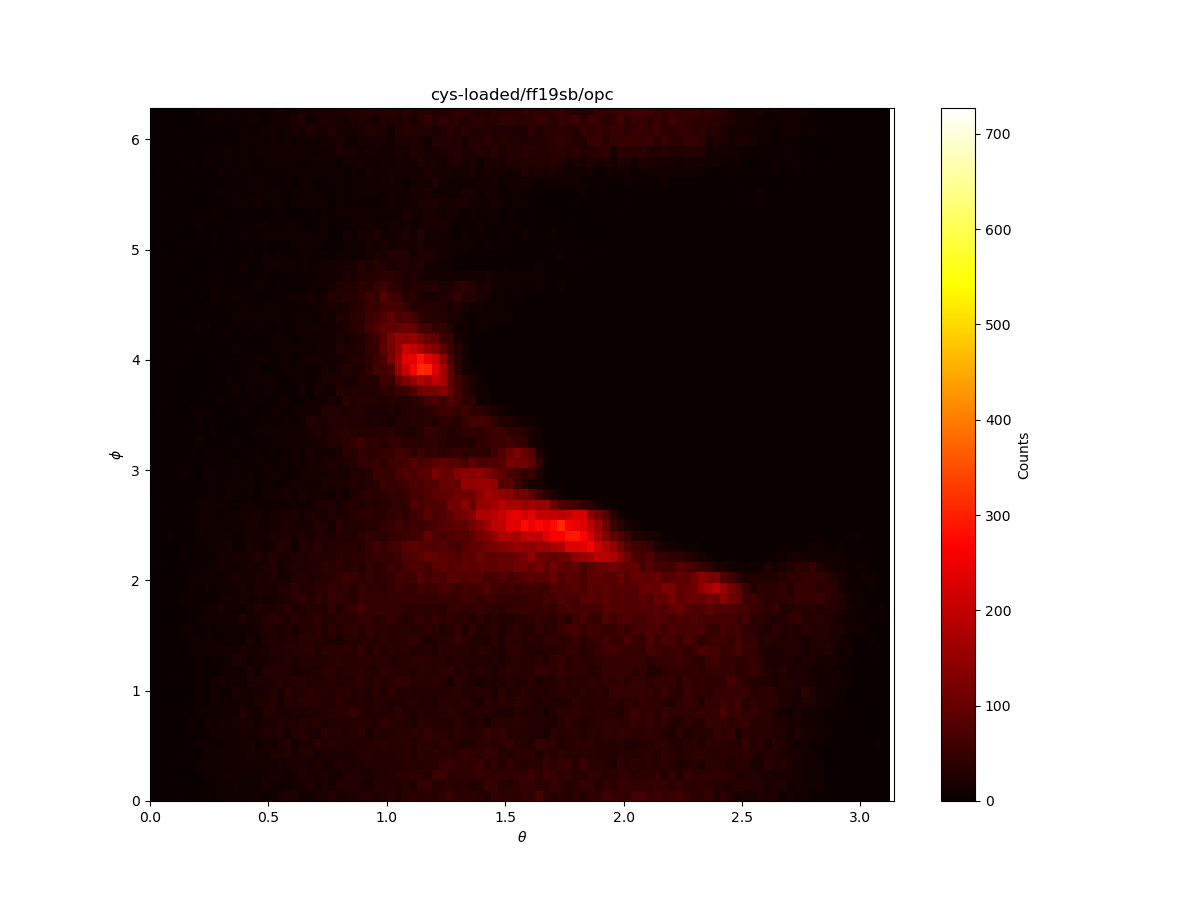

In [18]:
# theta spans [0, pi], phi spans [0, 2*pi] -- twice the range -- so phi needs
# twice as many bins as theta for each bin to cover the same angular width
# (pi/n_bins_theta == 2*pi/n_bins_phi), making bins appear square.
n_bins_theta = 100
n_bins_phi = n_bins_theta * 2
hist_bins = [n_bins_theta, n_bins_phi]

# Shared colorbar vmax across all states/prefixes, so the same bin count
# maps to the same color in every plot below instead of each state
# saturating at its own peak.
shared_vmax = max(
    np.histogram2d(theta_tiled, phi_tiled, bins=hist_bins)[0].max()
    for theta_tiled, phi_tiled in cv_data.values()
)

for prefix, (theta_tiled, phi_tiled) in cv_data.items():
    plt.figure(figsize=(12,9))
    h, xedges, yedges, image = plt.hist2d(theta_tiled, phi_tiled, bins=hist_bins, cmap="hot", cmin=0, vmax=shared_vmax)
    plt.colorbar(label="Counts")
    plt.title(f"{prefix}")
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\phi$")
    plt.xlim(0, np.pi)
    plt.ylim(0, 2*np.pi)
    plt.show()